In [4]:
!pip install pandas numpy matplotlib seaborn scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
# ==========================================
# SETUP & IMPORTS
# ==========================================
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Ensure charts directory exists
os.makedirs("charts", exist_ok=True)
print("Setup complete! 'charts' folder is ready.\n")

# Set plotting style
sns.set_theme(style="whitegrid")

# ==========================================
# TASK 1: LOAD & EXPLORE DATA
# ==========================================
print("--- TASK 1: Loading Data ---")
df = pd.read_csv("Housing.csv")
display(df.head(5))

# ==========================================
# TASK 2: DATA CLEANING (THIS WAS MISSING!)
# ==========================================
print("\n--- TASK 2: Cleaning Data & Creating X/y ---")
# Drop duplicates
df = df.drop_duplicates()

# Isolate categorical columns and apply One-Hot Encoding
categorical_cols = df.select_dtypes(include=['object']).columns
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Prepare final feature matrix (X) and target vector (y)
X = df_encoded.drop('price', axis=1)
y = df_encoded['price']
print("Successfully created X (features) and y (target)!\n")


Setup complete! 'charts' folder is ready.

--- TASK 1: Loading Data ---


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished



--- TASK 2: Cleaning Data & Creating X/y ---
Successfully created X (features) and y (target)!



In [6]:

# ==========================================
# TASK 3: MODEL TRAINING & EVALUATION
# ==========================================
print("--- TASK 3: Training Models ---")
# Split data into train and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# --- Train Linear Regression ---
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

# --- Train Random Forest ---
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

# --- Evaluation Function ---
def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return round(mae, 2), round(rmse, 2), round(r2, 4)

lr_metrics = evaluate_model(y_test, lr_preds)
rf_metrics = evaluate_model(y_test, rf_preds)

# --- Create Comparison Table ---
comparison_df = pd.DataFrame({
    'Metric': ['MAE (Lower is better)', 'RMSE (Lower is better)', 'R² Score (Higher is better)'],
    'Linear Regression': lr_metrics,
    'Random Forest': rf_metrics
})

print("\n--- Model Performance Comparison ---")
display(comparison_df)

--- TASK 3: Training Models ---

--- Model Performance Comparison ---


,Metric,Linear Regression,Random Forest
0,MAE (Lower is better),9.700434e+05,1.021546e+06
1,RMSE (Lower is better),1.324507e+06,1.400566e+06
2,R² Score (Higher is better),6.529000e-01,6.119000e-01


In [7]:
!pip install python-docx


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


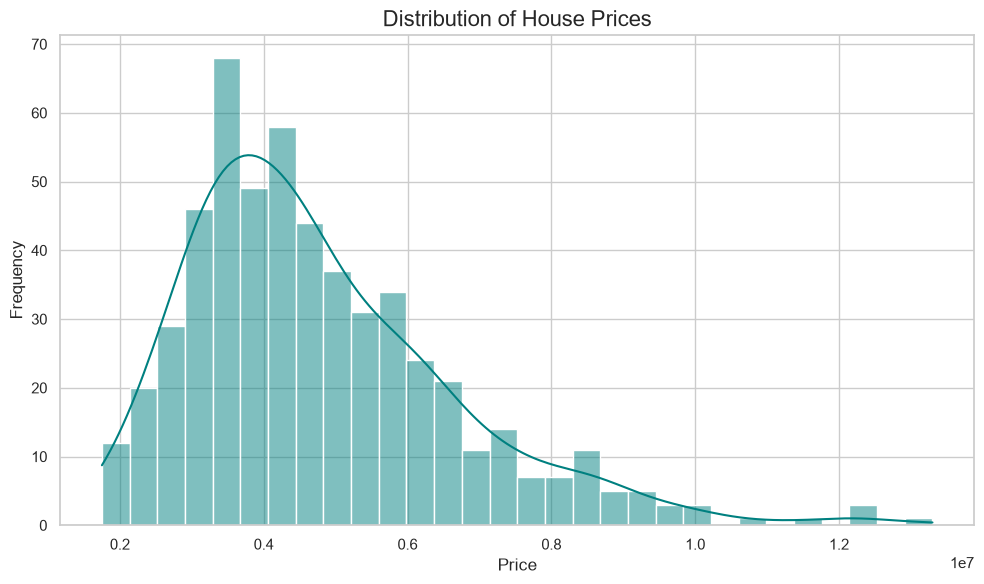

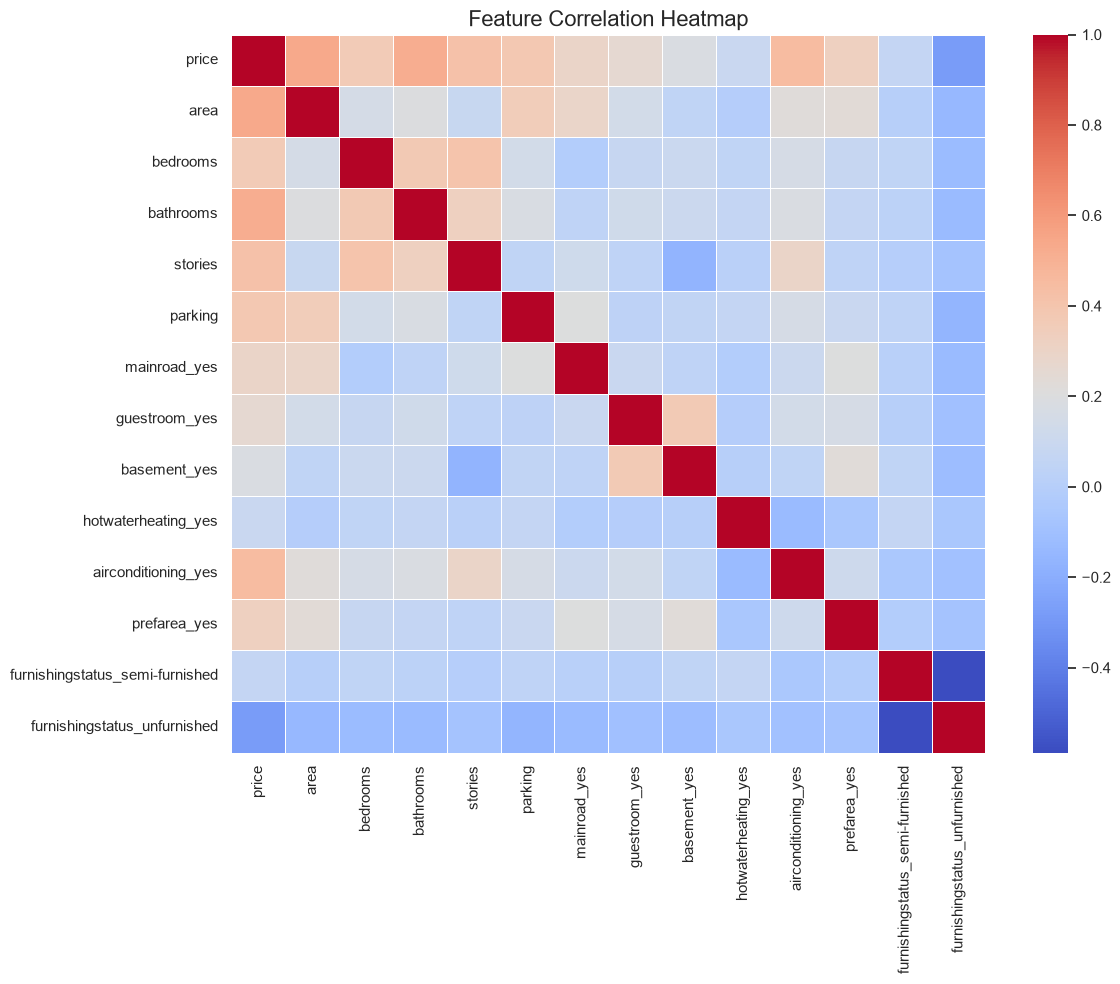

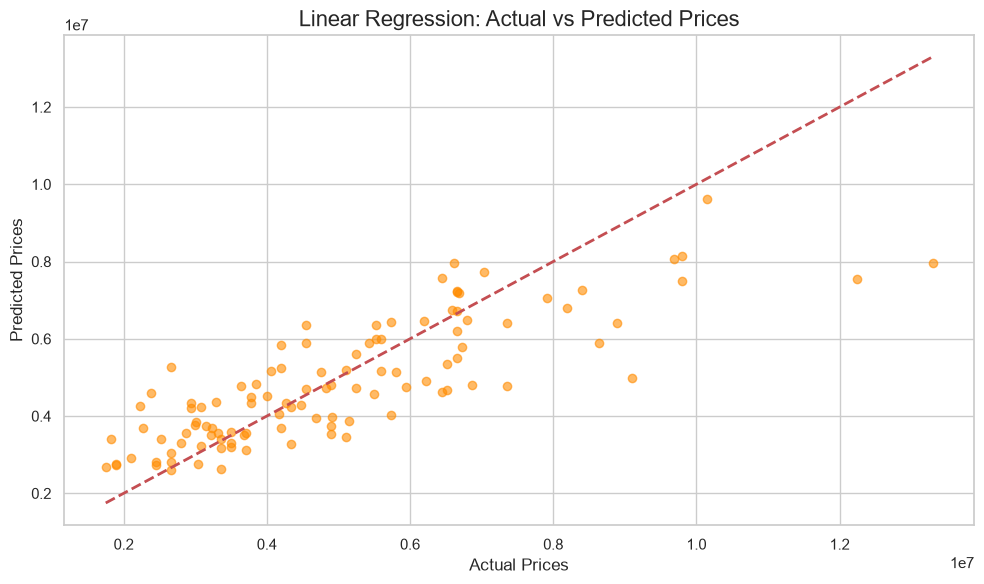

In [8]:
# ==========================================
# TASK 4: VISUALIZATIONS
# ==========================================

# Chart 1: Histogram of house prices
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], bins=30, kde=True, color='teal')
plt.title('Distribution of House Prices', fontsize=16)
plt.xlabel('Price', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.savefig('charts/price_distribution.png', dpi=300)
plt.show()

# Chart 2: Correlation heatmap of all features
plt.figure(figsize=(12, 10))
corr_matrix = df_encoded.corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=16)
plt.tight_layout()
plt.savefig('charts/correlation_heatmap.png', dpi=300)
plt.show()

# Chart 3: Actual vs Predicted Price Scatter Plot (Winning Model: Linear Regression)
plt.figure(figsize=(10, 6))
plt.scatter(y_test, lr_preds, alpha=0.6, color='darkorange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Perfect prediction line
plt.title('Linear Regression: Actual vs Predicted Prices', fontsize=16)
plt.xlabel('Actual Prices', fontsize=12)
plt.ylabel('Predicted Prices', fontsize=12)
plt.tight_layout()
plt.savefig('charts/actual_vs_predicted.png', dpi=300)
plt.show()

In [9]:
!python export_summary.py

Successfully generated an accurate summary.docx!


In [11]:
!cd

C:\Users\adity\HousePricePrediction_Aditya


In [12]:
!git init

Initialized empty Git repository in C:/Users/adity/HousePricePrediction_Aditya/.git/


In [ ]:
!git config --global user.name "adityarawattech-ai"
!git config --global user.email "adityarawat.tech@gmail.com"